In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
df=pd.read_csv('/content/Ecommerce_Sales_Data_2024_2025.csv', parse_dates=['Order Date'])
df.describe()

,Order ID,Order Date,Quantity,Unit Price,Discount,Sales,Profit
count,5000.000000,5000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,12500.500000,2024-09-30 18:58:27.840000,2.992600,39760.904600,10.051000,106733.204870,15941.746982
min,10001.000000,2023-10-04 00:00:00,1.000000,222.000000,0.000000,264.100000,19.120000
25%,11250.750000,2024-04-05 00:00:00,2.000000,20312.250000,5.000000,39766.537500,4892.295000
50%,12500.500000,2024-09-29 00:00:00,3.000000,39459.500000,10.000000,83080.325000,11108.525000
75%,13750.250000,2025-03-30 00:00:00,4.000000,59721.750000,15.000000,156968.587500,22467.987500
max,15000.000000,2025-10-03 00:00:00,5.000000,79998.000000,20.000000,398485.000000,89688.440000
std,1443.520003,NaN,1.413133,22831.783946,7.084662,85108.208202,14897.684916


In [4]:
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,2024-10-19,Kashvi Varty,South,Bangalore,Books,Non-Fiction,Non-Fiction Ipsum,2,36294,5,68958.6,10525.09,Debit Card
1,10002,2025-08-30,Advik Desai,North,Delhi,Groceries,Rice,Rice Nemo,1,42165,20,33732.0,6299.66,Debit Card
2,10003,2023-11-04,Rhea Kalla,East,Patna,Kitchen,Juicer,Juicer Odio,4,64876,20,207603.2,19850.27,Credit Card
3,10004,2025-05-23,Anika Sen,East,Kolkata,Groceries,Oil,Oil Doloribus,5,37320,15,158610.0,36311.02,UPI
4,10005,2025-01-19,Akarsh Kaul,West,Pune,Clothing,Kids Wear,Kids Wear Quo,1,50037,10,45033.3,9050.04,Debit Card


In [9]:
#preprocessing
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['Product Name']=le.fit_transform(df['Product Name'])
df.head()

,Order ID,Order Date,Customer Name,Region,City,Category,Sub-Category,Product Name,Quantity,Unit Price,Discount,Sales,Profit,Payment Mode
0,10001,380,Kashvi Varty,South,Bangalore,Books,Non-Fiction,2258,2,36294,5,68958.6,10525.09,Debit Card
1,10002,695,Advik Desai,North,Delhi,Groceries,Rice,2720,1,42165,20,33732.0,6299.66,Debit Card
2,10003,30,Rhea Kalla,East,Patna,Kitchen,Juicer,1589,4,64876,20,207603.2,19850.27,Credit Card
3,10004,596,Anika Sen,East,Kolkata,Groceries,Oil,2327,5,37320,15,158610.0,36311.02,UPI
4,10005,472,Akarsh Kaul,West,Pune,Clothing,Kids Wear,1676,1,50037,10,45033.3,9050.04,Debit Card


In [10]:
# Check for missing values
print("Missing values per column:")
display(df.isnull().sum())

Missing values per column:


,0
Order ID,0
Order Date,0
Customer Name,0
Region,0
City,0
Category,0
Sub-Category,0
Product Name,0
Quantity,0
Unit Price,0


In [11]:
# Check for duplicate rows
print(f"Number of duplicate rows: {df.duplicated().sum()}")

Number of duplicate rows: 0


In [12]:
# Check data types and non-null counts
print("Data types and non-null counts:")
df.info()

Data types and non-null counts:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   int64  
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   int64  
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(6), object(6)
memory usage: 547.0+ KB


### Sales Trend Analysis

In [17]:
# Extract time-based features
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order DayOfWeek'] = df['Order Date'].dt.dayofweek # Monday=0, Sunday=6
df['Order MonthYear'] = df['Order Date'].dt.to_period('M')

display(df[['Order Date', 'Order Year', 'Order Month', 'Order DayOfWeek', 'Order MonthYear']].head())

,Order Date,Order Year,Order Month,Order DayOfWeek,Order MonthYear
0,2024-10-19,2024,10,5,2024-10
1,2025-08-30,2025,8,5,2025-08
2,2023-11-04,2023,11,5,2023-11
3,2025-05-23,2025,5,4,2025-05
4,2025-01-19,2025,1,6,2025-01


#### Monthly Sales Trend

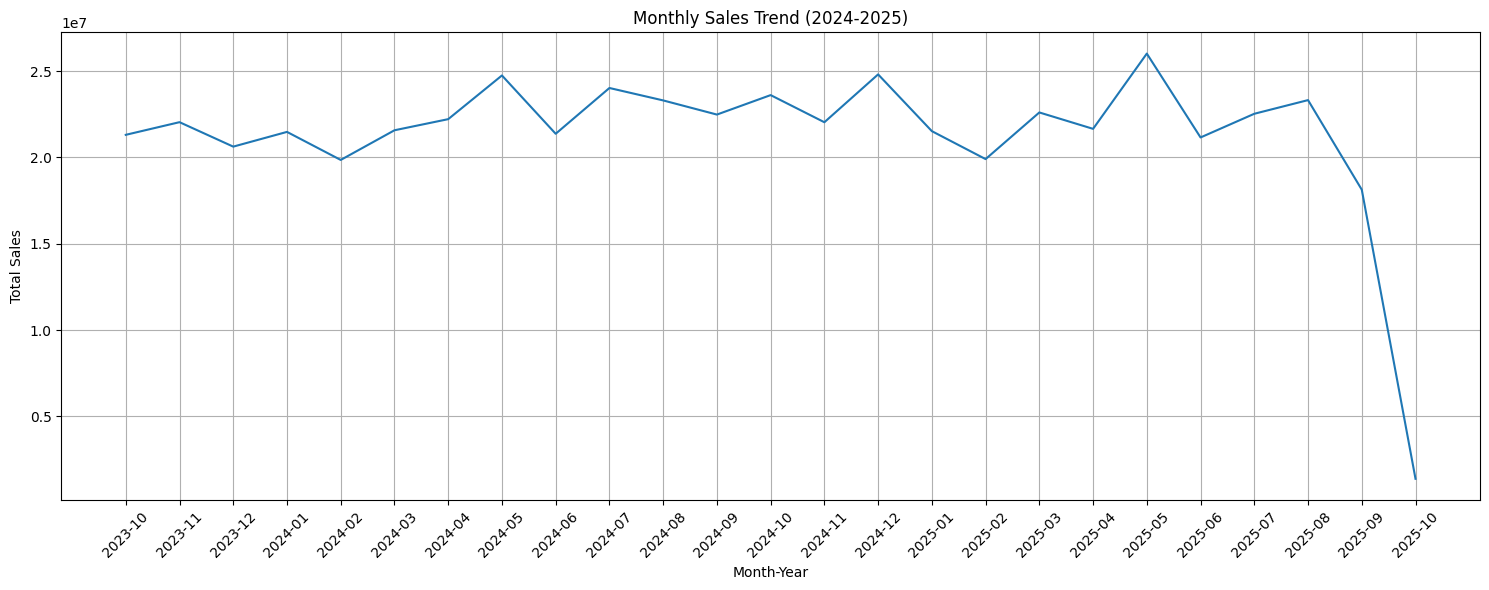

In [18]:
monthly_sales = df.groupby('Order MonthYear')['Sales'].sum().reset_index()
monthly_sales['Order MonthYear'] = monthly_sales['Order MonthYear'].astype(str)

plt.figure(figsize=(15, 6))
sns.lineplot(x='Order MonthYear', y='Sales', data=monthly_sales)
plt.title('Monthly Sales Trend (2024-2025)')
plt.xlabel('Month-Year')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

#### Sales by Category

/tmp/ipykernel_692/3438341572.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Category', y='Sales', data=sales_by_category, palette='viridis')


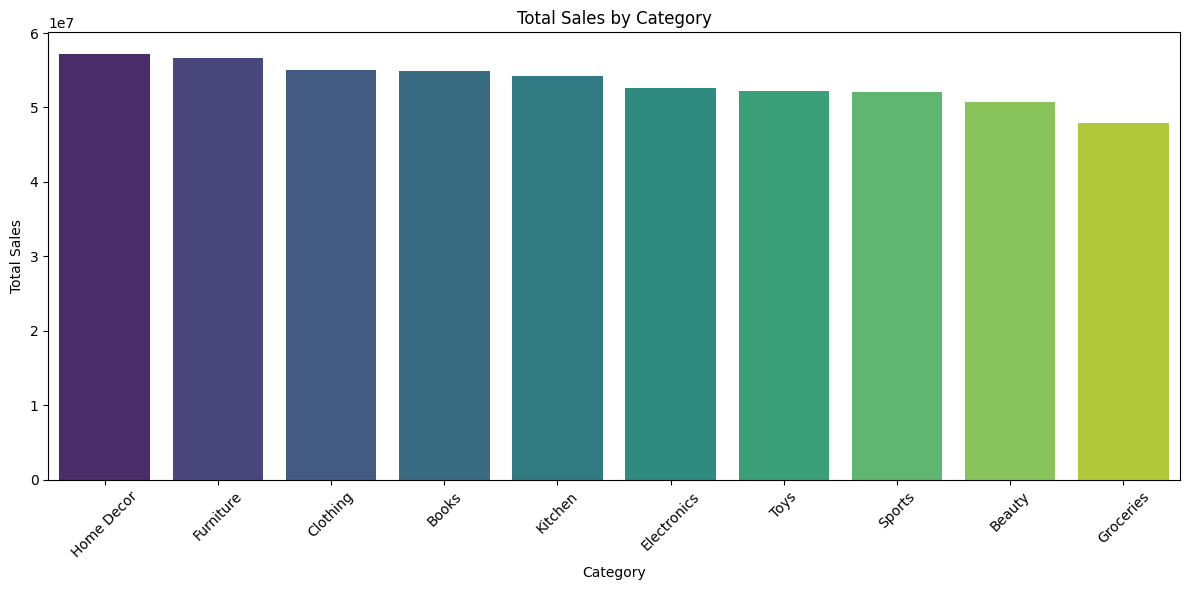

In [19]:
sales_by_category = df.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(12, 6))
sns.barplot(x='Category', y='Sales', data=sales_by_category, palette='viridis')
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

#### Sales by Region

/tmp/ipykernel_692/4220819409.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Sales', data=sales_by_region, palette='magma')


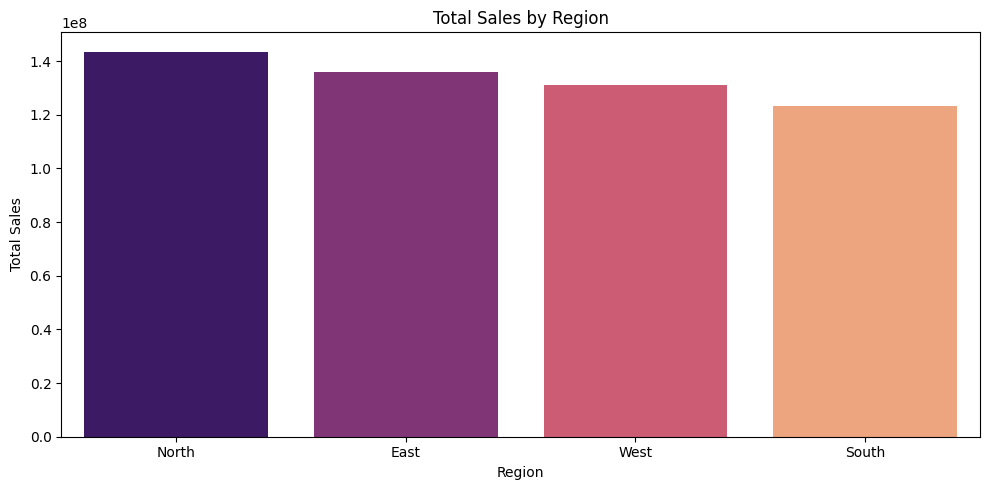

In [20]:
sales_by_region = df.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Region', y='Sales', data=sales_by_region, palette='magma')
plt.title('Total Sales by Region')
plt.xlabel('Region')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()

#### Sales by Payment Mode

/tmp/ipykernel_692/2677912442.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Payment Mode', y='Sales', data=sales_by_payment_mode, palette='cubehelix')


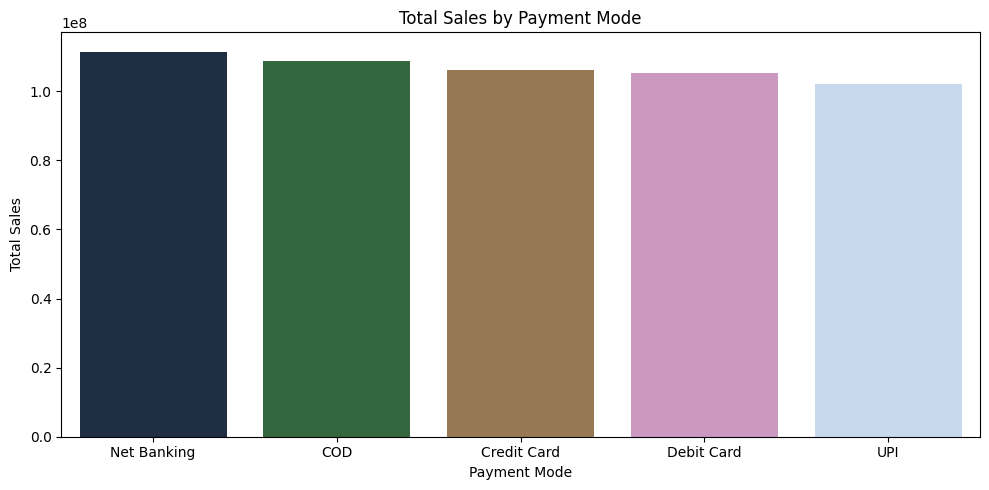

In [21]:
sales_by_payment_mode = df.groupby('Payment Mode')['Sales'].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='Payment Mode', y='Sales', data=sales_by_payment_mode, palette='cubehelix')
plt.title('Total Sales by Payment Mode')
plt.xlabel('Payment Mode')
plt.ylabel('Total Sales')
plt.tight_layout()
plt.show()